# **Arquitecturas benchmark: Segmentación de imágenes**

## **Librerías y modulos necesarios**

In [1]:
import os
import sys
import cv2
import glob
import timm
import random
import warnings
import numpy as np
import pandas as pd
from glob import glob
import seaborn as sns
import tensorflow as tf
from joblib import dump, load
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
warnings.filterwarnings("ignore")
from tensorflow.keras.metrics import *
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import SGD, Adam, schedules
from tensorflow.keras import layers, models, losses, optimizers
from sklearn.metrics import roc_curve, precision_recall_curve, balanced_accuracy_score
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, Activation, Multiply, Add,Concatenate,
                                     GlobalAveragePooling2D, AveragePooling2D, UpSampling2D, BatchNormalization, Dense, Dropout, GlobalMaxPool2D)

## **Funciones para resultados**

En esta sección, se definen funciones para visualizar las gráficas de cada arquitectura o modelo, con el objetivo de reducir la repetición de código.

### **Evaluación del modelo**

En este caso mostraremos la máscara binarizada ya que es fundamental en la segmentación de tumores en ultrasonidos, permite evaluar con claridad qué tan bien el modelo ha identificado la región de interés. Al reducir los valores a 0 y 1, se facilita la comparación con la máscara real (ground truth), lo que es esencial para calcular métricas como IoU, Dice Coefficient y Recall de manera precisa. Además, su visualización sobre la imagen original ayuda a detectar posibles errores, como la inclusión de ruido o la omisión de partes del tumor.

In [5]:
def evaluar_modelo(model, X_test, y_test, n = 5, nombre_modelo = "Modelo"):
    """
    Visualiza la segmentación de un modelo en imágenes aleatorias del conjunto de prueba.

    Parámetros:
    - model: modelo de segmentación
    - X_test: conjunto de imágenes de prueba
    - y_test: máscaras reales de prueba
    - n: número de imágenes a visualizar (default = 5)
    - nombre_modelo: nombre del modelo para la figura
    """

    j = np.random.randint(0, X_test.shape[0], n)  # Selecciona n imágenes aleatorias
    fig, ax = plt.subplots(n, 5, figsize=(15, 4 * n))  # n filas, 5 columnas

    for i in range(n):
        img = X_test[j[i]]  # Imagen original
        gt_mask = y_test[j[i]]  # Ground truth
        pred_mask = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]  # Predicción
        binary_pred = (pred_mask > 0.5).astype(np.float32)  # Binarización

        img = img.squeeze()
        gt_mask = gt_mask.squeeze()
        pred_mask = pred_mask.squeeze()
        binary_pred = binary_pred.squeeze()

        ax[i, 0].imshow(img, cmap='gray')
        ax[i, 0].set_title('Imagen original')
        ax[i, 0].axis("off")

        ax[i, 1].imshow(gt_mask, cmap='gray')
        ax[i, 1].set_title('Ground Truth')
        ax[i, 1].axis("off")

        ax[i, 2].imshow(pred_mask, cmap='gray')
        ax[i, 2].set_title('Predicción')
        ax[i, 2].axis("off")

        ax[i, 3].imshow(binary_pred, cmap='gray', vmin=0, vmax=1)
        ax[i, 3].set_title('Máscara Binaria')
        ax[i, 3].axis("off")

        ax[i, 4].imshow(img, cmap='gray')  # Imagen original
        ax[i, 4].imshow(pred_mask, cmap='jet', alpha=0.5)  # Superposición con transparencia
        ax[i, 4].set_title('Superposición Predicción')
        ax[i, 4].axis("off")

    fig.suptitle(f'Comparación Visual - {nombre_modelo}', fontsize=18)
    plt.tight_layout()
    plt.show()

### **Curvas de evaluación (Loss and accuracy)**

In [6]:
def graficar_historial(history, nombre_modelo="Modelo"):
    """
    Grafica la evolución de la pérdida y precisión durante el entrenamiento.

    Parámetros:
    - history: historial de entrenamiento del modelo (history.history de Keras)
    - nombre_modelo: nombre del modelo para el título de la figura
    """

    best_epoch = np.argmax(history.history["val_iou_metric"])  # Mejor época (máxima val_iou_metric)
    best_val_acc = history.history["val_iou_metric"][best_epoch]  # Mejor val_iou_metric
    best_val_loss = history.history["val_loss"][best_epoch]  # Pérdida en la mejor época

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].plot(history.epoch, history.history["loss"], label="Train loss", color="#8B0A50")  # Rosa oscuro
    ax[0].plot(history.epoch, history.history["val_loss"], label="Validation loss", color="#FF1493")  # Rosa fuerte
    ax[0].scatter(best_epoch, best_val_loss, color='r', marker='x', s=100, label="Best val_loss")  # "X" en mejor modelo
    ax[0].legend()
    ax[0].set_title("Loss")
    ax[0].grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    ax[1].plot(history.epoch, history.history["iou_metric"], label="Train iou_metric", color="#8B0A50")
    ax[1].plot(history.epoch, history.history["val_iou_metric"], label="Validation iou_metric",color="#FF1493")
    ax[1].scatter(best_epoch, best_val_acc, color='r', marker='x', s=100, label="Best val_iou_metric")  # "X" en mejor modelo
    ax[1].legend()
    ax[1].set_title("Iou_metric")
    ax[1].grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    fig.suptitle(f'Loss and Accuracy - {nombre_modelo}', fontsize=16)
    plt.show()


### **Mapas de error**

In [7]:
def visualizar_segmentacion(model, X_test, y_test, nombre_modelo="Modelo"):
    """
    Visualiza la segmentación con la imagen original, la máscara real (GT), la predicción binarizada
    y el mapa de errores (FP y FN).

    Parámetros:
    - model: modelo de segmentación entrenado
    - X_test: imágenes de prueba
    - y_test: máscaras de prueba
    - nombre_modelo: nombre del modelo para el título
    """

    # Seleccionar 5 imágenes aleatorias
    j = np.random.randint(0, X_test.shape[0], 5)

    fig, ax = plt.subplots(5, 4, figsize=(15, 18))  # 4 columnas: Original, GT, Predicción, Error

    for i in range(5):
        img = np.squeeze(X_test[j[i]])  # Imagen original
        gt_mask = np.squeeze(y_test[j[i]])  # Ground truth (máscara real)
        pred_mask = model.predict(np.expand_dims(X_test[j[i]], 0), verbose=0)[0]  # Predicción
        binary_pred = np.squeeze((pred_mask > 0.5).astype(np.float32))  # Binarización

        # Calcular Falsos Positivos y Falsos Negativos
        false_positives = (binary_pred == 1) & (gt_mask == 0)  # FP (Predicho 1, pero era 0)
        false_negatives = (binary_pred == 0) & (gt_mask == 1)  # FN (Predicho 0, pero era 1)

        # Crear imagen de error en RGB
        error_map = np.zeros((*gt_mask.shape, 3))  # Imagen RGB vacía
        error_map[..., 0] = false_positives  # Rojo para FP
        error_map[..., 2] = false_negatives  # Azul para FN

        # Imagen original
        ax[i, 0].imshow(img, cmap='gray')
        ax[i, 0].set_title('Imagen Original')
        ax[i, 0].axis("off")

        # Ground Truth (Máscara real)
        ax[i, 1].imshow(gt_mask, cmap='gray')
        ax[i, 1].set_title('Ground Truth')
        ax[i, 1].axis("off")

        # Predicción del modelo
        ax[i, 2].imshow(binary_pred, cmap='gray', vmin=0, vmax=1)
        ax[i, 2].set_title('Predicción Binarizada')
        ax[i, 2].axis("off")

        # Mapa de error
        ax[i, 3].imshow(img, cmap='gray')  # Imagen base
        ax[i, 3].imshow(error_map, alpha=0.6)  # Superposición de errores
        ax[i, 3].set_title('Mapa de Errores (FP: Rojo, FN: Azul)')
        ax[i, 3].axis("off")

    fig.suptitle(f'Análisis de Errores en Segmentación - {nombre_modelo}', fontsize=18)
    plt.tight_layout()
    plt.show()

### **Curvas de evaluación**

In [8]:
def plot_roc_pr_curves(y_test, y_pred):
    # Aplanar imágenes
    y_true_flat = y_test.flatten().astype(int)  # Convertir a binario (0 o 1)
    y_pred_flat = y_pred.flatten()  # Mantener probabilidades originales

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true_flat, y_pred_flat)

    # Curva Precision-Recall
    precision, recall, _ = precision_recall_curve(y_true_flat, y_pred_flat)

    # Estilo del grid
    grid_style = dict(color='gray', linestyle='--', linewidth=0.6, alpha=0.7)

    # Graficar Curva ROC
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='blue', linewidth=2)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)  # Línea aleatoria
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.grid(**grid_style)

    # Graficar Curva Precision-Recall
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='green', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.grid(**grid_style)

    plt.tight_layout()
    plt.show()

### **Boxplots para dispersión de métricas**

In [9]:
def boxplots(y_test, y_pred, threshold=0.5):
    """
    Calcula métricas de segmentación y genera un boxplot con su distribución.

    Parámetros:
    - y_test: Array de máscaras reales.
    - y_pred: Array de predicciones de la red neuronal (probabilidades).
    - threshold: Umbral para binarizar las predicciones.
    """
    # Listas para almacenar métricas de cada muestra
    dice_scores = []
    iou_scores = []
    precision_scores = []
    recall_scores = []
    auc_scores = []
    balanced_acc_scores = []

    # Iterar sobre cada muestra en el dataset
    for i in range(len(y_test)):
        y_true = y_test[i].flatten().astype(int)  # Aplanar y binarizar
        y_pred_prob = y_pred[i].flatten()  # Probabilidades originales
        y_pred_binary = (y_pred_prob > threshold).astype(int)  # Aplicar umbral

        # Dice Coefficient
        intersection = np.sum(y_pred_binary * y_true)
        union = np.sum(y_pred_binary) + np.sum(y_true)
        dice = (2. * intersection) / (union + 1e-7)
        dice_scores.append(dice)

        # IoU (Jaccard Index)
        iou = intersection / (union - intersection + 1e-7)
        iou_scores.append(iou)

        # Precision y Recall
        precision = np.sum(y_pred_binary * y_true) / (np.sum(y_pred_binary) + 1e-7)
        recall = np.sum(y_pred_binary * y_true) / (np.sum(y_true) + 1e-7)
        precision_scores.append(precision)
        recall_scores.append(recall)

        # AUC con TensorFlow
        auc_metric = tf.keras.metrics.AUC()
        auc_metric.update_state(y_true, y_pred_binary)
        auc_value = auc_metric.result().numpy()
        auc_scores.append(auc_value)

        # Balanced Accuracy
        balanced_acc = balanced_accuracy_score(y_true, y_pred_binary)
        balanced_acc_scores.append(balanced_acc)

    # Crear DataFrame con métricas
    df_metrics = pd.DataFrame({
        "Dice Coefficient": dice_scores,
        "IoU": iou_scores,
        "Precision": precision_scores,
        "Recall": recall_scores,
        "AUC": auc_scores,
        "Balanced Accuracy": balanced_acc_scores
    })

    # Configurar estilo de gráficos
    sns.set_style("whitegrid")

    # Crear boxplots para cada métrica
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_metrics)
    plt.xticks(rotation=45)
    plt.title("Distribución de métricas - Boxplots")
    plt.show()


## **Conjuntos de entrenamiento y test**

Inicialmente, cargamos los conjuntos de imágenes y sus respectivas máscaras, previamente generadas durante el preprocesamiento y el análisis exploratorio de datos (EDA), las cuales están listas para la implementación de las arquitecturas.

In [10]:
X = np.load("/content/imagenes_cancer.npy")
y = np.load("/content/mascaras_cancer.npy")

En esta etapa, expandimos la dimensión de los conjuntos de imágenes (`X`) y sus respectivas máscaras (`y`) para adecuarlos al formato requerido por los modelos de segmentación. Luego, mostramos sus formas resultantes para verificar que la transformación se realizó correctamente.

In [11]:
X = np.expand_dims(X, -1)
y = np.expand_dims(y, -1)

print(f"\nForma de X: {X.shape}  |  Forma de y: {y.shape}")


Forma de X: (682, 128, 128, 1)  |  Forma de y: (682, 128, 128, 1)


Ahora, se mezclan aleatoriamente los datos antes de dividirlos, asegurando una distribución más equitativa en los conjuntos de entrenamiento y prueba. Para ello, se generan índices ordenados, se reorganizan aleatoriamente y luego se aplican a los conjuntos de imágenes (`X`) y sus respectivas máscaras (`y`).

In [12]:
# Mezclar aleatoriamente los datos antes de dividir
indices = np.arange(len(X))
random.seed(11)
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

Dividimos el conjunto de datos en entrenamiento y prueba, asignando un 90% para entrenamiento y un 10% para prueba. Esto nos permite evaluar el desempeño del modelo en datos no vistos mediante métricas calculadas sobre el conjunto de prueba. Posteriormente, dentro del conjunto de entrenamiento, realizamos una nueva división para obtener un subconjunto de validación. Esta separación es fundamental para monitorear el rendimiento del modelo durante el entrenamiento y ajustar hiperparámetros sin comprometer la evaluación final.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1,random_state = 11)
print('X_train shape:',X_train.shape)
print('y_train shape:',y_train.shape)
print('X_test shape:',X_test.shape)
print('y_test shape:',y_test.shape)

X_train shape: (613, 128, 128, 1)
y_train shape: (613, 128, 128, 1)
X_test shape: (69, 128, 128, 1)
y_test shape: (69, 128, 128, 1)


In [14]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state = 11)

In [15]:
print('X_train shape:',X_train.shape)
print('y_train shape:',y_train.shape)
print('X_val shape:',X_val.shape)
print('y_val shape:',y_val.shape)

X_train shape: (490, 128, 128, 1)
y_train shape: (490, 128, 128, 1)
X_val shape: (123, 128, 128, 1)
y_val shape: (123, 128, 128, 1)


## **Data Augmentation**

En esta sección, aplicamos **aumento de datos (Data Augmentation)** para mejorar la capacidad de generalización de los modelos de segmentación. Esto se logra aplicando transformaciones aleatorias, como rotaciones, escalado, volteo horizontal y vertical, a las imágenes y sus respectivas máscaras.  

`````{admonition} ¿Por qué se hace antes de entrenar los modelos?
:class: tip
El Data Augmentation permite generar variaciones de las imágenes originales, lo que ayuda a reducir el sobreajuste (overfitting) y mejora el rendimiento del modelo en datos no vistos. Al aplicar estas transformaciones durante el entrenamiento, el modelo aprende a reconocer patrones más robustos y generalizables.  
`````

`````{admonition}  ¿Por qué solo se usan los conjuntos de entrenamiento?
:class: tip
El conjunto de prueba (`X_test`, `y_test`) se reserva para evaluar el modelo sin alteraciones, asegurando que la evaluación refleje un rendimiento realista en datos no vistos. Si se aplicara Data Augmentation al conjunto de prueba, los resultados no serían representativos.  
`````


En este código, se define un diccionario con los parámetros de transformación y se usa `ImageDataGenerator` para aplicarlos tanto a las imágenes como a sus máscaras. Luego, `fit()` se encarga de ajustar el generador a los datos de entrenamiento, asegurando que las transformaciones se apliquen correctamente durante el proceso de entrenamiento del modelo.

In [16]:
data_gen_args = dict(
    rotation_range=60,  # Rotación aleatoria de hasta ±60 grados
    zoom_range=[0.6, 1.0],  # Zoom aleatorio entre 60% y 100% del tamaño original
    horizontal_flip=True,  # Permite voltear horizontalmente la imagen
    vertical_flip=True,  # Permite voltear verticalmente la imagen
    fill_mode="nearest"  # Método para rellenar píxeles vacíos tras la transformación
)


In [17]:
image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen = ImageDataGenerator(**data_gen_args)
seed = 1

In [18]:
image_datagen.fit(X_train, augment=True, seed=seed)
mask_datagen.fit(y_train, augment=True, seed=seed)

## **Implementación de modelos originales**

### **UNet ++**

U-Net++ es una evolución de la arquitectura original U-Net, diseñada para mejorar la precisión en tareas de segmentación semántica. Se caracteriza por una estructura encoder-decoder profundamente conectada que facilita una mejor transmisión de información y una reconstrucción más precisa de las máscaras segmentadas, especialmente útil en contextos médicos como la detección de tumores.



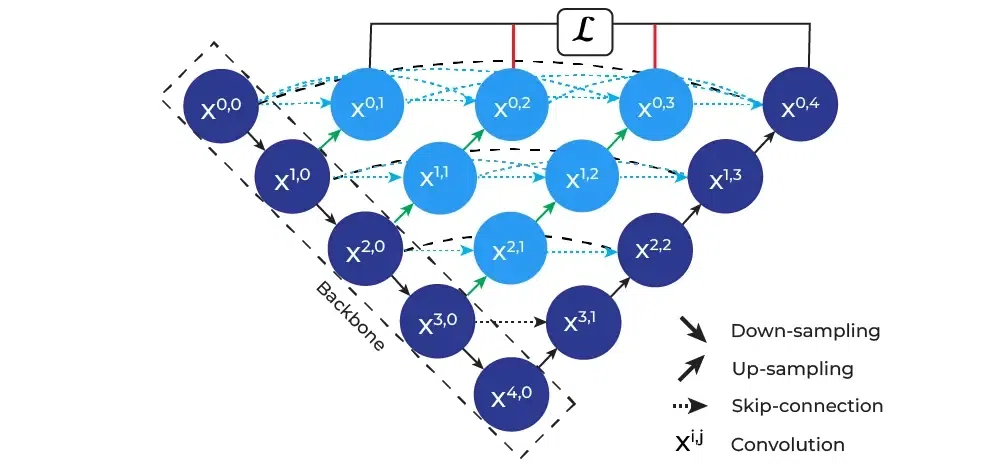

#### **Arquitectura y entrenamiento**

In [19]:
# Bloque convolucional con BatchNorm y ReLU
def conv_block(input_tensor, num_filters):
    x = Conv2D(num_filters, (3, 3), padding='same', kernel_initializer='he_normal')(input_tensor)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(num_filters, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    # x = Dropout(0.3)(x)  # Descomenta si quieres usar Dropout
    return x

# Encoder
def encoder_block(input_tensor, num_filters):
    conv = conv_block(input_tensor, num_filters)
    pool = MaxPooling2D(pool_size=(2, 2))(conv)
    return conv, pool

# Construcción del nested UNet++
def nested_unet(input_layer, num_filters_list):
    convs = {}  # Diccionario para almacenar nodos intermedios

    # Encoder
    x = input_layer
    for d, filters in enumerate(num_filters_list):
        convs[f'X{d}_0'], x = encoder_block(x, filters)

    # Nested decoder (U-Net++)
    depth = len(num_filters_list)
    for j in range(1, depth):
        for i in range(depth - j):
            concat_list = [convs[f'X{i}_{k}'] for k in range(j)]
            up = Conv2DTranspose(num_filters_list[i], (2, 2), strides=(2, 2), padding='same')(convs[f'X{i+1}_{j-1}'])
            concat_list.append(up)
            concat = concatenate(concat_list, axis=-1)
            convs[f'X{i}_{j}'] = conv_block(concat, num_filters_list[i])

    return convs[f'X0_{depth - 1}']  # Salida final

# Función para construir el modelo
def build_unetpp(input_shape=(128, 128, 1)):
    input_layer = Input(input_shape)
    output = nested_unet(input_layer, [64, 128, 256, 512])
    output_layer = Conv2D(1, (1, 1), activation='sigmoid')(output)
    return Model(inputs=input_layer, outputs=output_layer, name="UNetPlusPlus")

import tensorflow.keras.backend as K
import tensorflow as tf

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = K.sum(y_true * y_pred, axis=[1, 2, 3])
    union = K.sum(y_true + y_pred, axis=[1, 2, 3]) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return K.mean(iou)

# Construcción y compilación del modelo
model_unetpp = build_unetpp(input_shape=(128, 128, 1))

model_unetpp.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=[iou_metric])



In [20]:
checkpointer = [
    EarlyStopping(
        monitor='val_mean_io_u',
        verbose=1,
        restore_best_weights=True,
        mode='max',
        patience=10
    ),
    ModelCheckpoint(
        filepath='model.weights.best.keras',
        monitor='val_mean_io_u',
        verbose=1,
        save_best_only=True,
        mode='max'
    )
]

In [21]:
history_unet = None

if os.path.exists('history_unetplusplus.joblib'):
    history_unet = load('history_unetplusplus.joblib')
    print("El archivo 'history_unetplusplus.joblib' ya existe. Se ha cargado el historial del entrenamiento.")
else:
    history_unet = model_unetpp.fit(
    X_train, y_train,
    epochs=80,
    validation_data=(X_val, y_val),
    callbacks=checkpointer,
    verbose=2,
    batch_size=10
)

    dump(history_unet.history, 'history_unetplusplus.joblib')
    print("El entrenamiento se ha completado y el historial ha sido guardado en 'history_unetplusplus.joblib'.")

Epoch 1/80
49/49 - 71s - 1s/step - iou_metric: 0.0429 - loss: 0.3569 - val_iou_metric: 0.0962 - val_loss: 31.1302
Epoch 2/80
49/49 - 13s - 257ms/step - iou_metric: 0.2546 - loss: 0.2431 - val_iou_metric: 0.1495 - val_loss: 1.5992
Epoch 3/80
49/49 - 20s - 412ms/step - iou_metric: 0.3312 - loss: 0.2145 - val_iou_metric: 0.1512 - val_loss: 3.9046
Epoch 4/80
49/49 - 20s - 409ms/step - iou_metric: 0.3687 - loss: 0.2017 - val_iou_metric: 0.1643 - val_loss: 1.3249
Epoch 5/80
49/49 - 21s - 426ms/step - iou_metric: 0.4294 - loss: 0.1789 - val_iou_metric: 0.2838 - val_loss: 0.4544
Epoch 6/80
49/49 - 12s - 248ms/step - iou_metric: 0.4533 - loss: 0.1731 - val_iou_metric: 0.3364 - val_loss: 0.2416
Epoch 7/80
49/49 - 20s - 413ms/step - iou_metric: 0.4615 - loss: 0.1633 - val_iou_metric: 0.2403 - val_loss: 0.6304
Epoch 8/80
49/49 - 12s - 251ms/step - iou_metric: 0.4770 - loss: 0.1596 - val_iou_metric: 0.3544 - val_loss: 0.3023
Epoch 9/80
49/49 - 12s - 244ms/step - iou_metric: 0.4984 - loss: 0.1503 - 

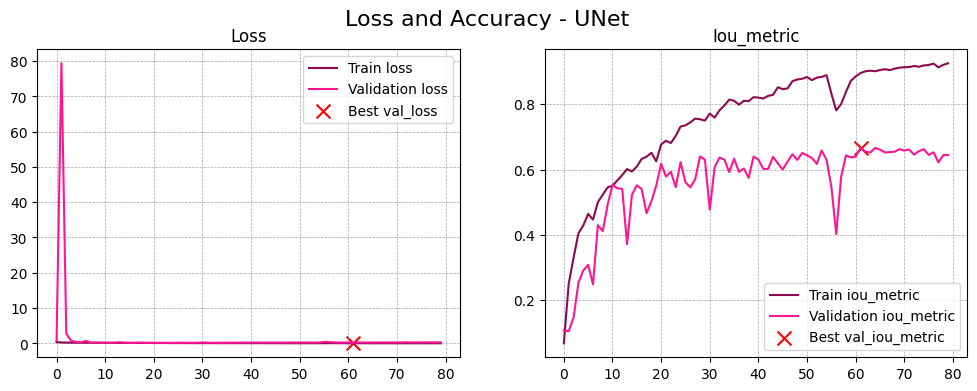

In [ ]:
graficar_historial(history_unet, nombre_modelo="UNet")

#### **Métricas de evaluación**

In [22]:
y_pred = model_unetpp.predict(X_test, verbose=0)
y_pred_thresholded = y_pred > 0.5
# Asegura que ambas tengan la forma (67, 128, 128, 1)
y_pred_thresholded = np.squeeze(y_pred_thresholded)
y_test = np.squeeze(y_test)

IOU_keras = MeanIoU(num_classes=2)
IOU_keras.update_state(y_pred_thresholded, y_test)
iou_score = IOU_keras.result().numpy()

prec_score = Precision()
prec_score.update_state(y_pred_thresholded, y_test)
p = prec_score.result().numpy()

recall_score = Recall()
recall_score.update_state(y_pred_thresholded, y_test)
r = recall_score.result().numpy()

auc_score = AUC()
auc_score.update_state(y_pred_thresholded, y_test)
auc = auc_score.result().numpy()


intersection = np.sum(y_pred_thresholded * y_test)
union = np.sum(y_pred_thresholded) + np.sum(y_test)
dice_coefficient = (2. * intersection) / (union + 1e-7)  # Evitar división por cero


balanced_accuracy = (p + r) / 2

metrics_dict = {
    "Dice Coefficient": dice_coefficient,
    "Mean IoU": iou_score,
    "Precision": p,
    "Recall": r,
    "AUC": auc,
    "Balanced Accuracy": balanced_accuracy}

df_metrics_unet = pd.DataFrame(metrics_dict, index=["Segmentación U-Net++"])
df_metrics_unet.to_csv("resultados_unet.csv")
df_metrics_unet

,Dice Coefficient,Mean IoU,Precision,Recall,AUC,Balanced Accuracy
Segmentación U-Net++,0.752717,0.780022,0.690351,0.827392,0.900871,0.758872


Las métricas globales obtenidas por el modelo U-Net++ reflejan un rendimiento sólido pero ligeramente inferior en comparación con la arquitectura V-Net++. Se observa un coeficiente de Dice de aproximadamente 0.75 y un IoU medio de 0.78, lo que indica una buena superposición entre las máscaras predichas y las reales, aunque con algo menos de precisión en los bordes o en casos más complejos. La precisión (0.69) sugiere que el modelo tiende a cometer más falsos positivos, mientras que el recall (0.82) evidencia una mayor sensibilidad para detectar las regiones verdaderamente positivas. El AUC (0.90) y la Balanced Accuracy (0.75) respaldan un comportamiento consistente del modelo, aunque se aprecia que su rendimiento puede verse afectado en casos específicos —posiblemente por estructuras pequeñas o etiquetas de baja calidad— lo cual coincide con la variabilidad observada en la distribución de métricas. En conjunto, el desempeño es aceptable, pero con espacio para mejoras en la capacidad del modelo para adaptarse a estructuras más sutiles o menos definidas.

#### **Comparación visual**

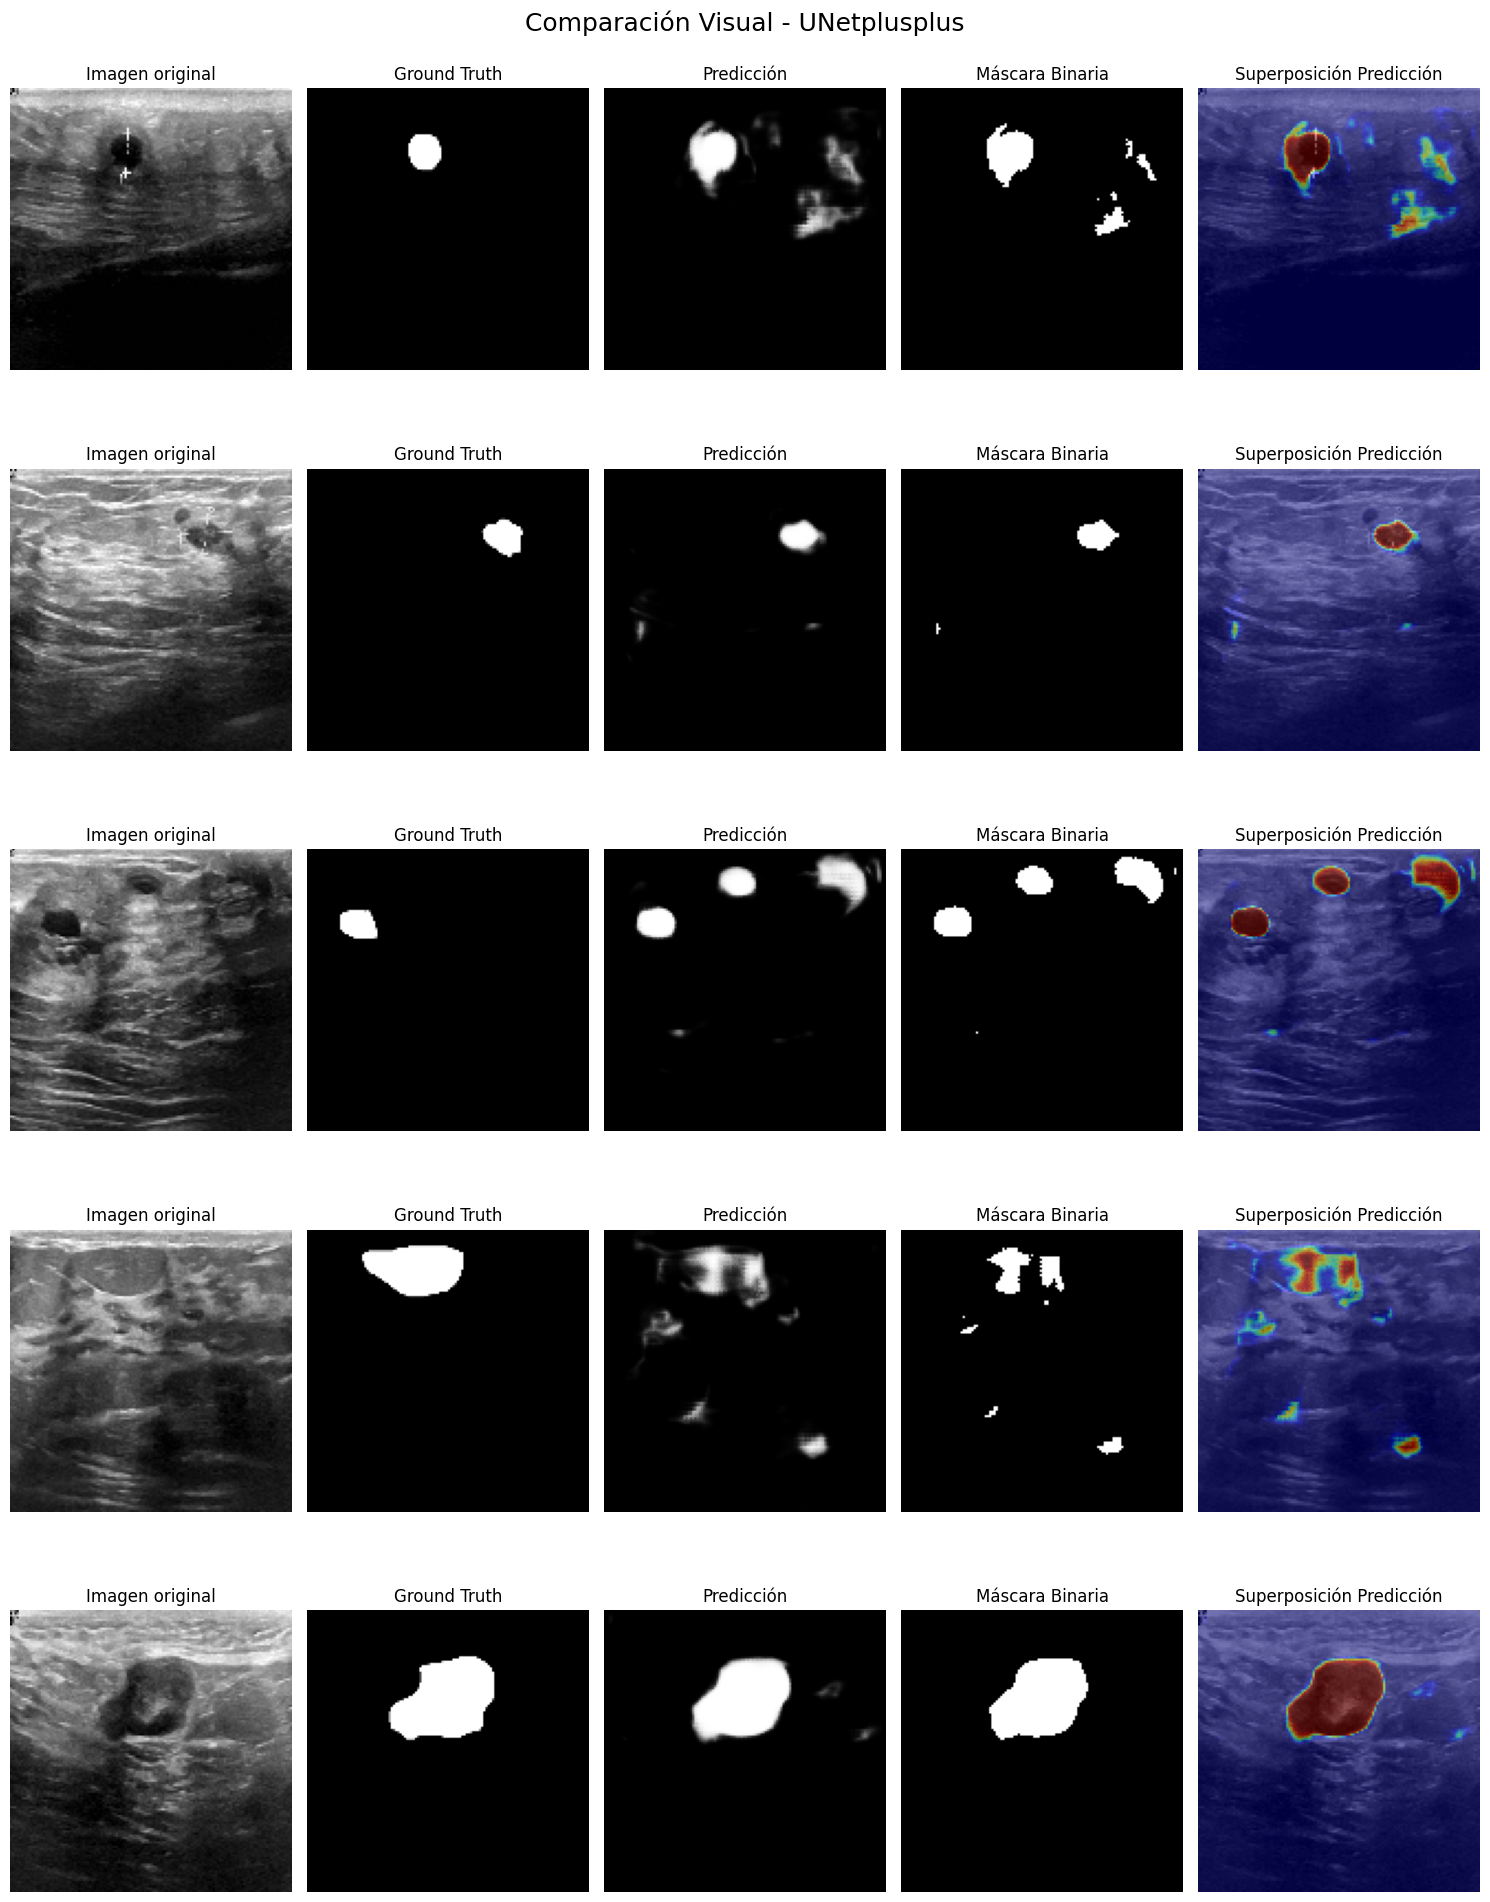

In [23]:
evaluar_modelo(model_unetpp, X_test, y_test, nombre_modelo="UNetplusplus")

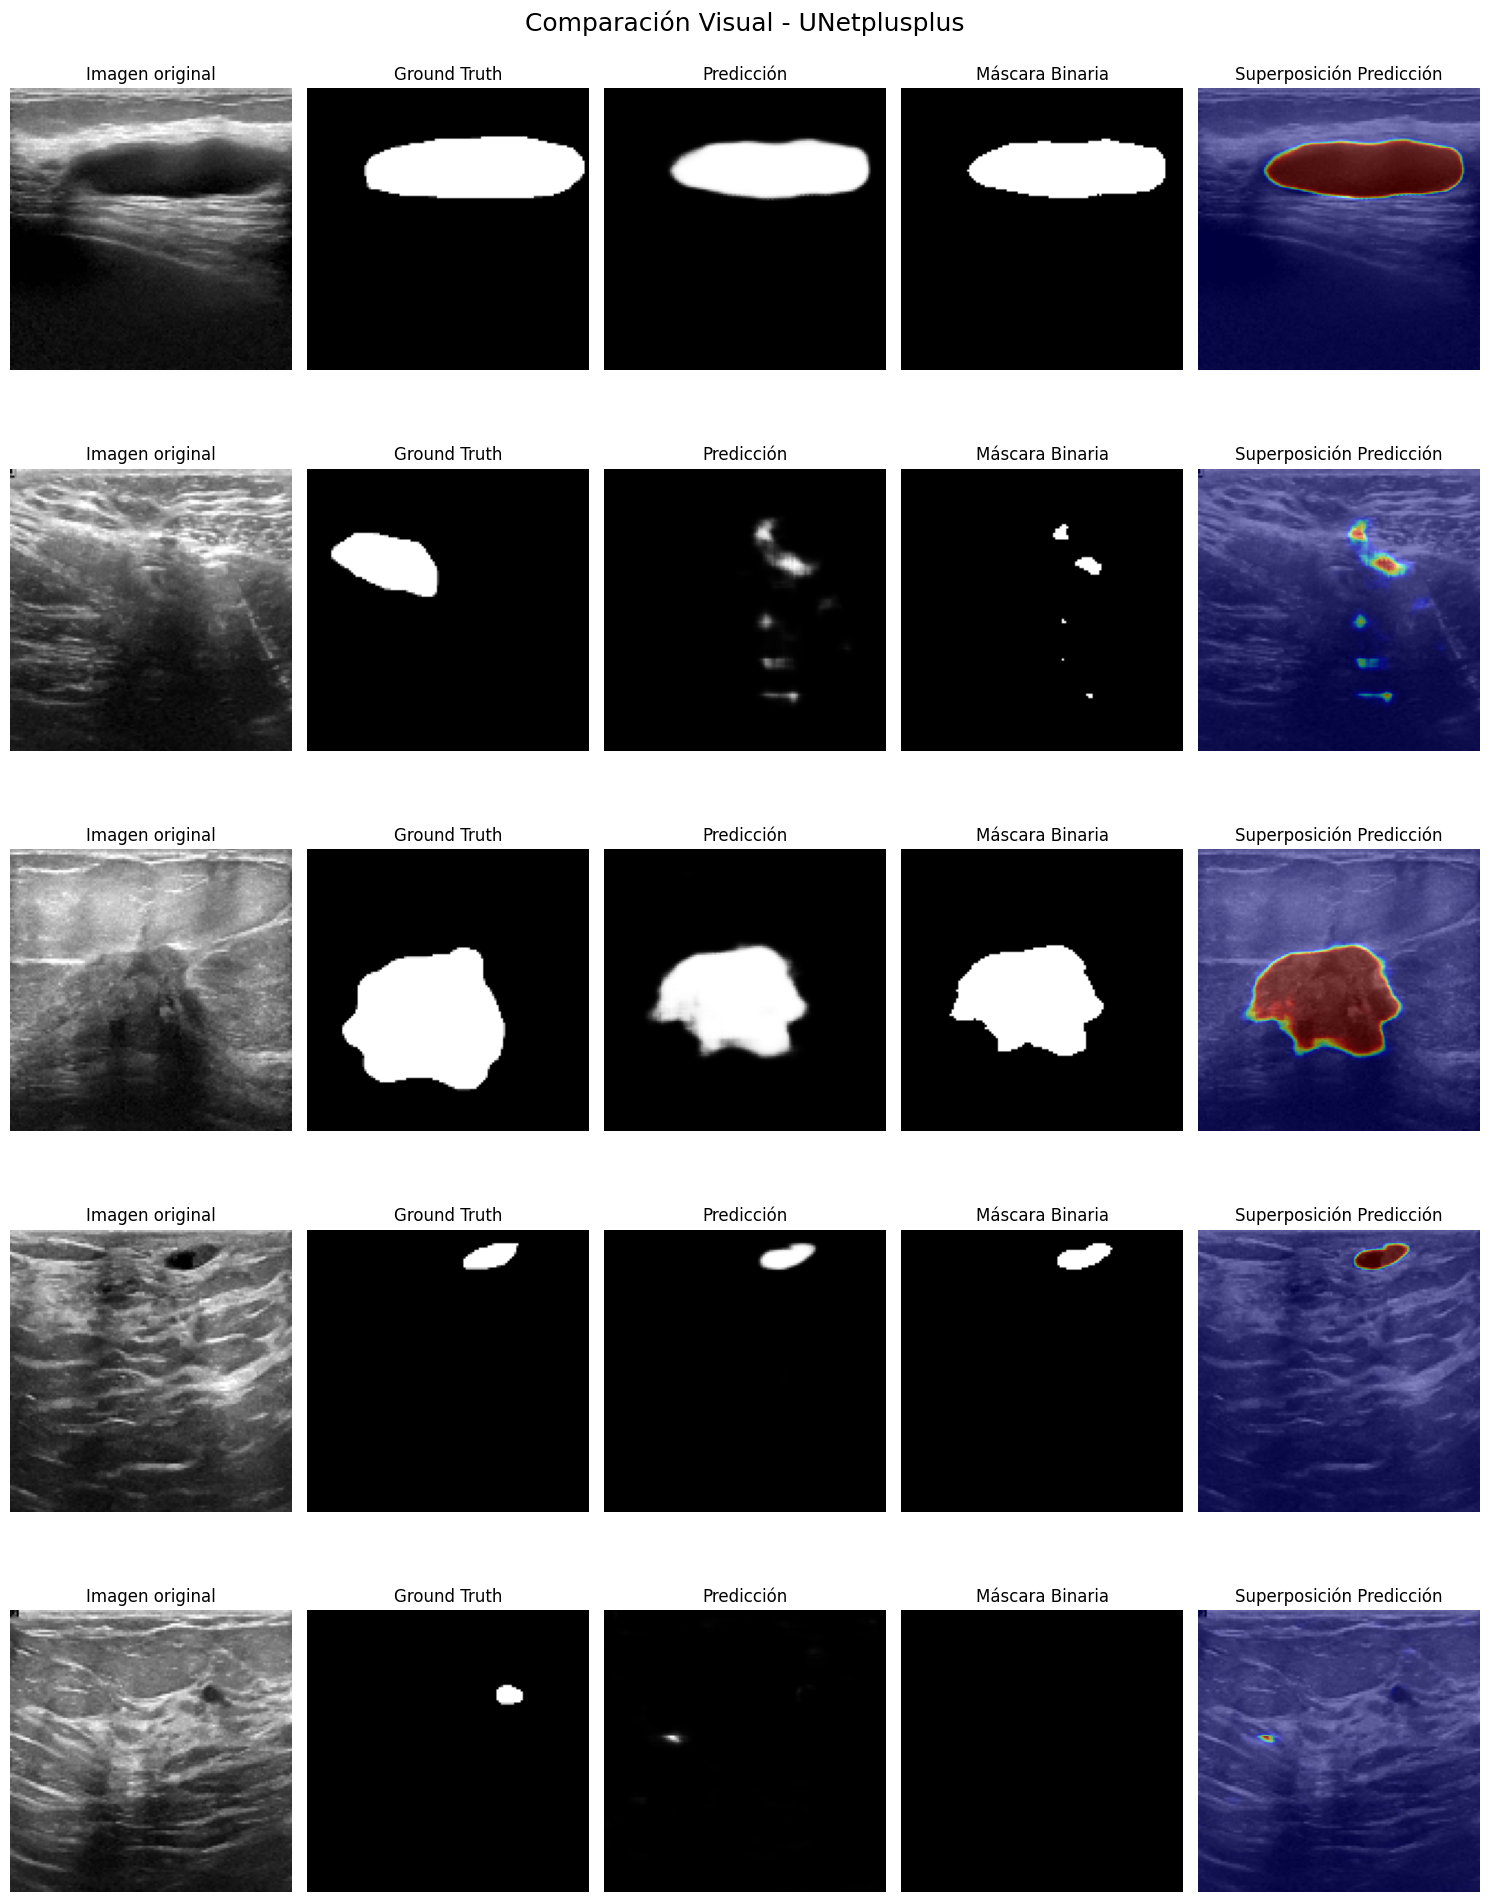

In [ ]:
evaluar_modelo(model_unetpp, X_test, y_test, nombre_modelo="UNetplusplus")

#### **Mapas de error**

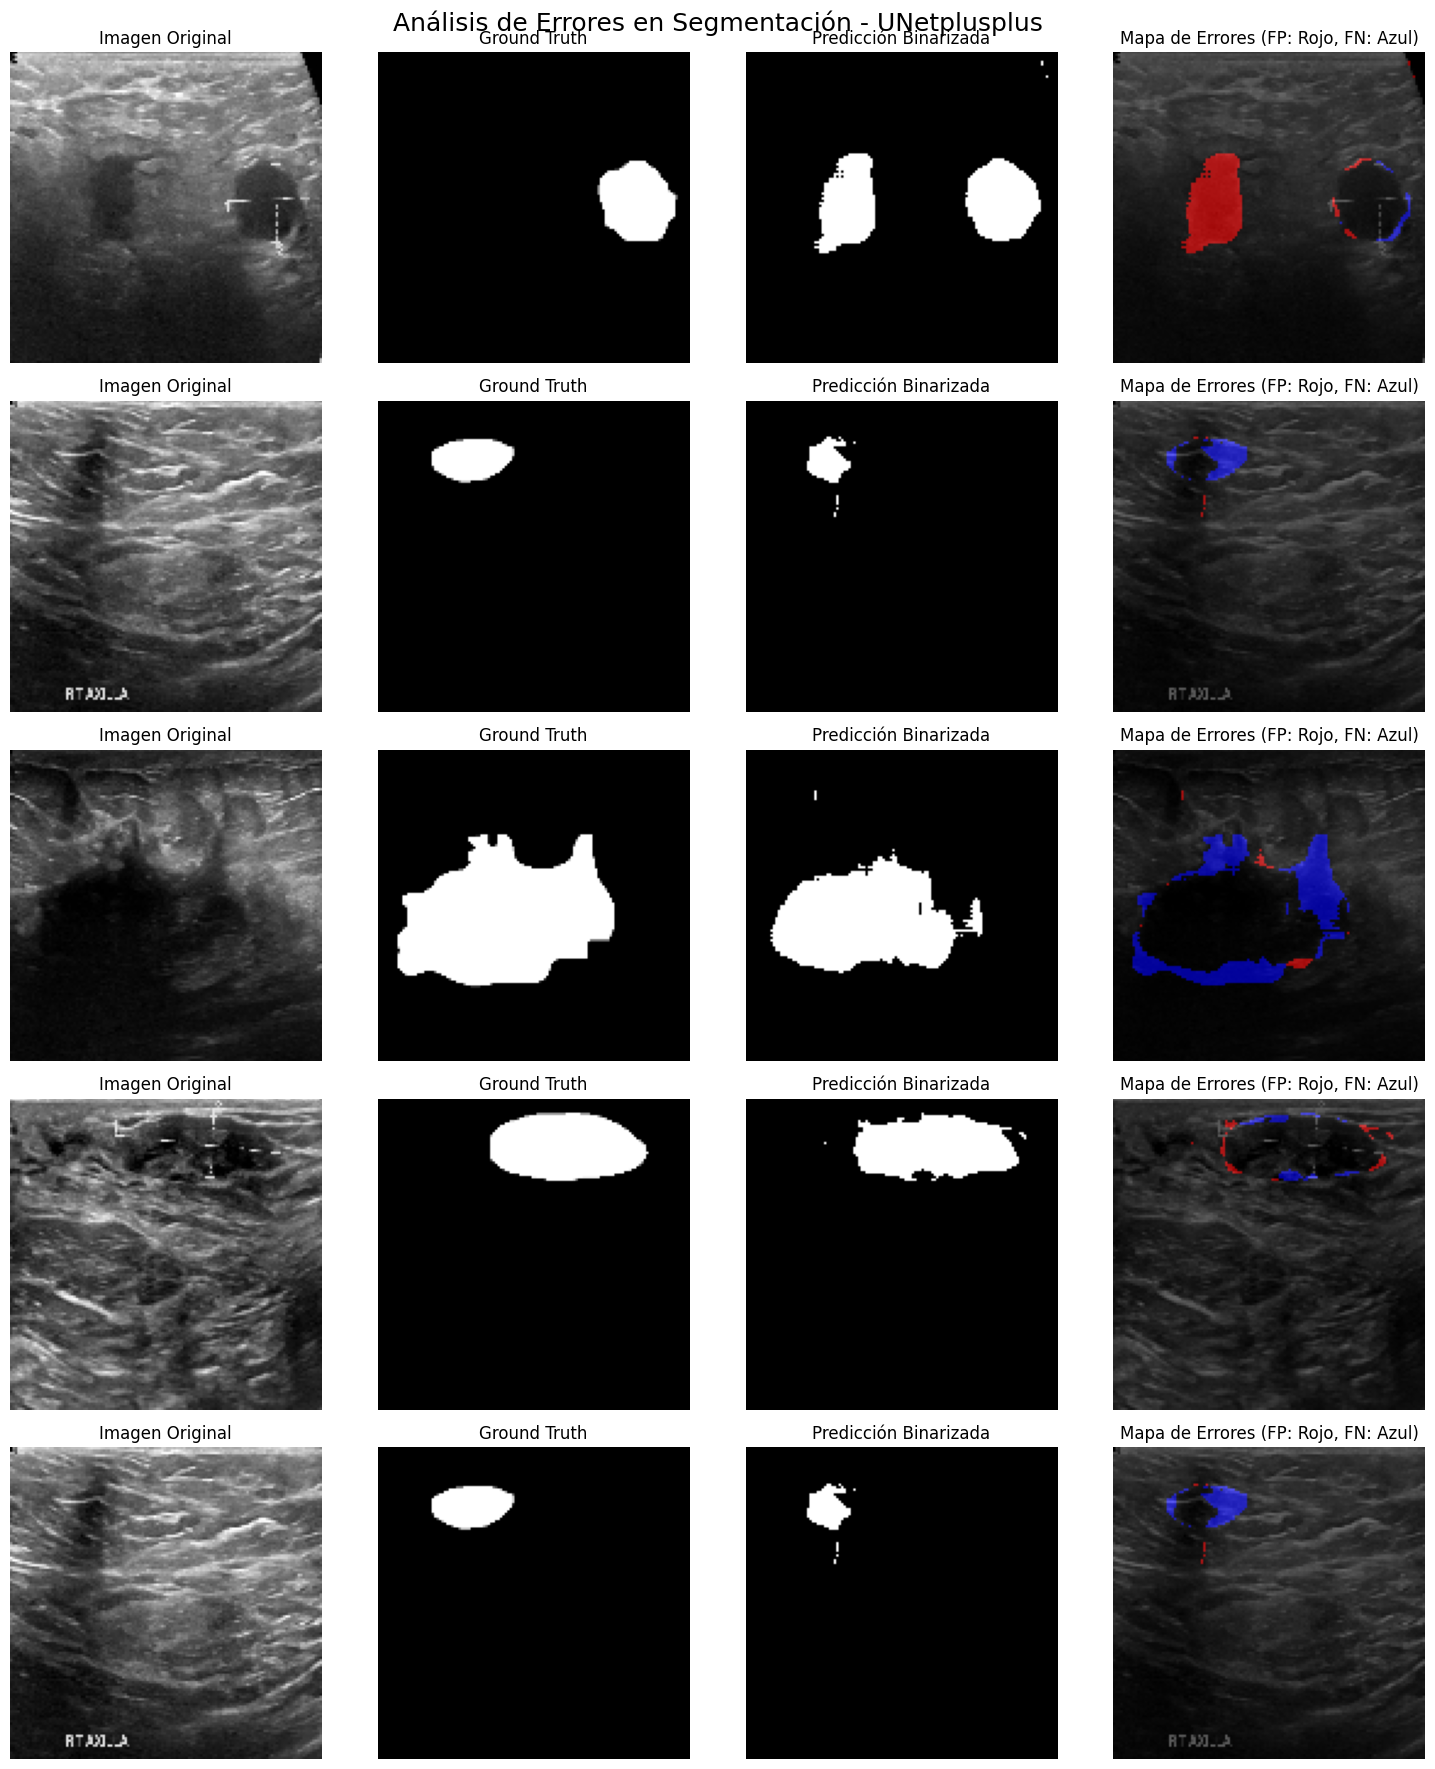

In [24]:
visualizar_segmentacion(model_unetpp, X_test, y_test, nombre_modelo="UNetplusplus")

En el comportamiento observado, se evidencia que el modelo U-Net++ logra capturar adecuadamente las regiones tumorales en la mayoría de los casos, mostrando un desempeño fuerte y generalizado en métricas como Precision y Recall. No obstante, cuando se presentan estructuras de menor tamaño o menos definidas, el modelo tiende a tener mayor dificultad para segmentarlas con precisión. Esto se refleja en los valores bajos de ciertas métricas en algunos ejemplos específicos, lo que sugiere que el modelo puede estar penalizándose excesivamente en estos casos. Es probable que estas caídas de rendimiento estén influenciadas tanto por la complejidad anatómica de ciertas imágenes como por posibles inconsistencias o limitaciones en la calidad de las etiquetas, especialmente si estas no logran representar completamente las estructuras presentes. Esto abre una línea de análisis interesante respecto al proceso de anotación, ya que una segmentación poco precisa en el ground truth puede afectar injustamente la evaluación del modelo.

#### **Curvas de evaluación**

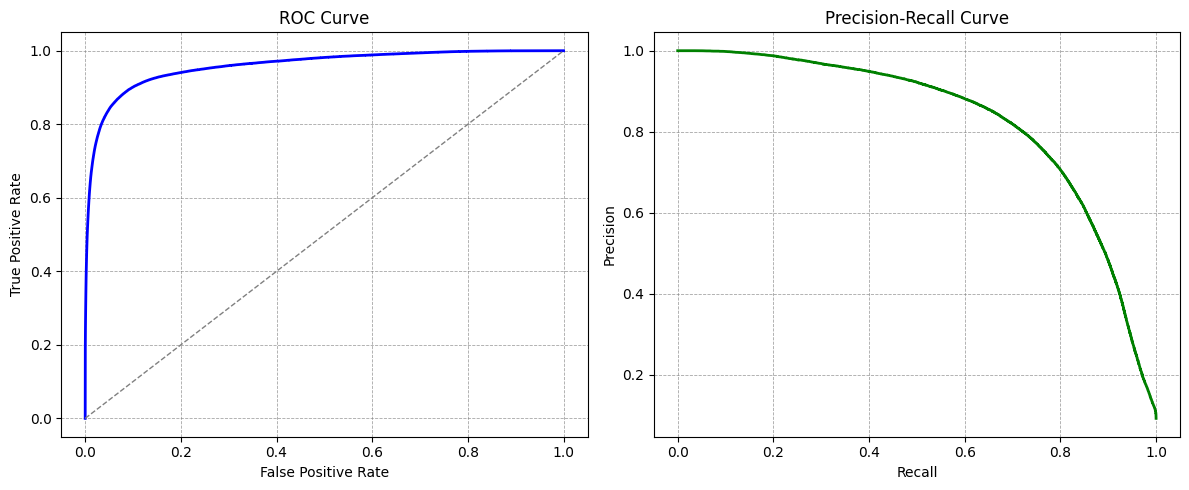

In [25]:
plot_roc_pr_curves(y_test, y_pred)

#### **Distribución de métricas**

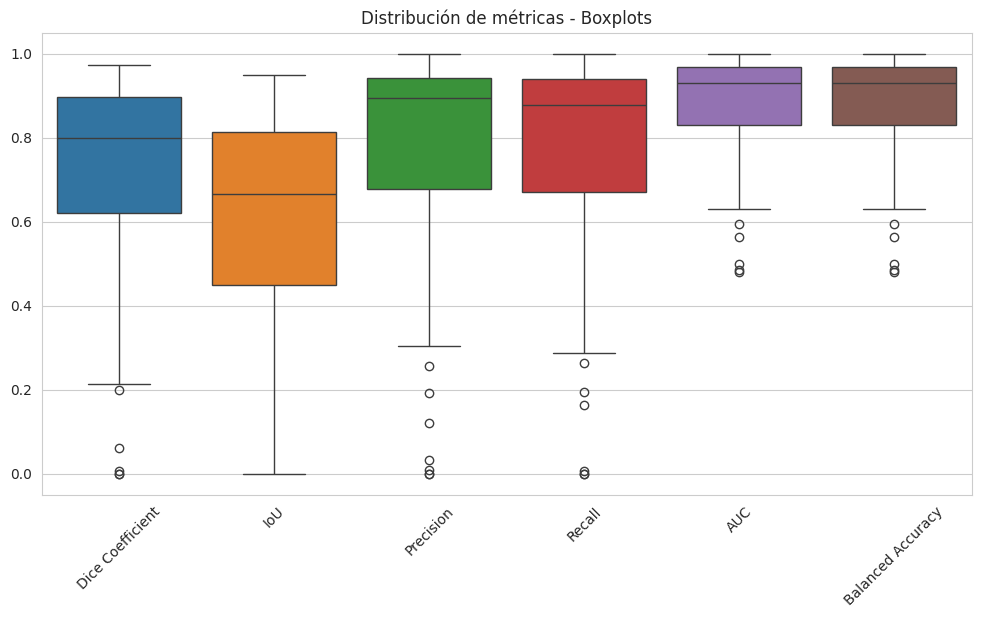

In [26]:
boxplots(y_test, y_pred)

En la imagen se observa un desempeño bastante consistente del modelo U-Net++ en la tarea de segmentación. Las métricas como Precision, Recall, AUC y Balanced Accuracy presentan distribuciones concentradas en valores altos (en torno a 0.9), lo cual indica una capacidad sólida del modelo para identificar correctamente las regiones de interés, con pocas falsas negativas. Sin embargo, tanto el Dice Coefficient como el IoU muestran mayor dispersión y presencia de valores atípicos bajos, lo que sugiere que en algunos casos el modelo no logra una superposición precisa entre las máscaras predichas y las reales. Esto podría deberse a imágenes con estructuras más complejas o a inconsistencias en el etiquetado, que afectan directamente estas métricas sensibles al solapamiento. En general, el modelo muestra un rendimiento robusto, aunque todavía hay ejemplos donde la segmentación puede ser mejorada.









### **Vnet++**

La arquitectura desarrollada es una variante híbrida de la V-Net++, diseñada específicamente para tareas de segmentación binaria en imágenes médicas de tamaño 128x128x1. Esta red incorpora bloques residuales profundos y un diseño tipo encoder-decoder con conexiones tipo nested skip connections, lo cual permite una mejor preservación de la información espacial y una reconstrucción precisa de las máscaras segmentadas.



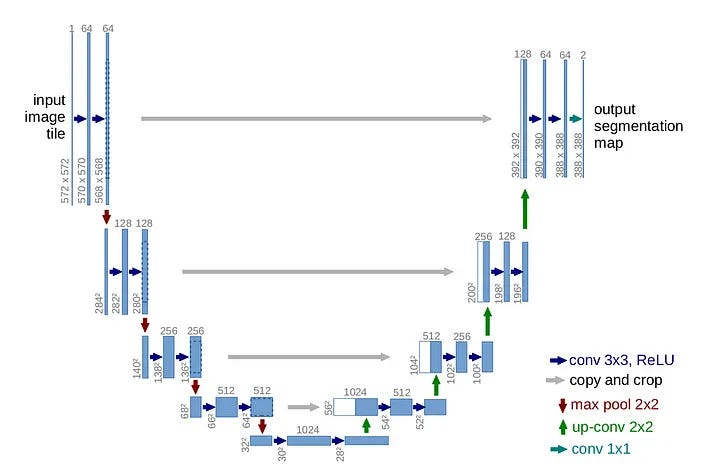

#### **Arquitectura y entrenamiento**

In [27]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, MaxPooling2D, Add, concatenate, BatchNormalization, PReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def residual_block(input_tensor, num_filters):
    x = Conv2D(num_filters, 3, padding="same", kernel_initializer="he_normal")(input_tensor)
    x = BatchNormalization()(x)
    x = PReLU()(x)
    x = Conv2D(num_filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = BatchNormalization()(x)

    shortcut = Conv2D(num_filters, 1, padding="same")(input_tensor)
    shortcut = BatchNormalization()(shortcut)

    out = Add()([x, shortcut])
    out = PReLU()(out)
    return out

def encoder_block(x, num_filters):
    res = residual_block(x, num_filters)
    pool = MaxPooling2D(pool_size=(2, 2))(res)
    return res, pool

def decoder_block(x, skip, num_filters):
    up = Conv2DTranspose(num_filters, 2, strides=2, padding="same")(x)
    concat = concatenate([up, skip])
    return residual_block(concat, num_filters)

def build_vnet_hybrid(input_shape=(128, 128, 1)):
    inputs = Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # Bottleneck
    b = residual_block(p4, 1024)

    # Decoder con conexiones múltiples (tipo nested)
    d1 = decoder_block(b, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = Conv2D(1, 1, activation="sigmoid")(d4)

    return Model(inputs, outputs, name="VNetPlusPlus")

import tensorflow.keras.backend as K
import tensorflow as tf

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = K.sum(y_true * y_pred, axis=[1, 2, 3])
    union = K.sum(y_true + y_pred, axis=[1, 2, 3]) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return K.mean(iou)

# Construcción y compilación del modelo
model_vnetpp = build_vnet_hybrid(input_shape=(128, 128, 1))

model_vnetpp.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=[iou_metric])


In [28]:
checkpointer = [
    EarlyStopping(
        monitor='val_mean_io_u',
        verbose=1,
        restore_best_weights=True,
        mode='max',
        patience=10
    ),
    ModelCheckpoint(
        filepath='model.weights.best.keras',
        monitor='val_mean_io_u',
        verbose=1,
        save_best_only=True,
        mode='max'
    )
]

In [29]:
history_vnet = None

if os.path.exists('history_vnetplusplus.joblib'):
    history_unet = load('history_vnetplusplus.joblib')
    print("El archivo 'history_vnetplusplus.joblib' ya existe. Se ha cargado el historial del entrenamiento.")
else:
    history_vnet = model_vnetpp.fit(
    X_train, y_train,
    epochs=80,
    validation_data=(X_val, y_val),
    callbacks=checkpointer,
    verbose=2,
    batch_size=10
)

    dump(history_vnet.history, 'history_vnetplusplus.joblib')
    print("El entrenamiento se ha completado y el historial ha sido guardado en 'history_vnetplusplus.joblib'.")

Epoch 1/80
49/49 - 66s - 1s/step - iou_metric: 0.2255 - loss: 0.2388 - val_iou_metric: 0.1015 - val_loss: 87.8765
Epoch 2/80
49/49 - 12s - 237ms/step - iou_metric: 0.3859 - loss: 0.1803 - val_iou_metric: 0.1665 - val_loss: 4.1351
Epoch 3/80
49/49 - 20s - 405ms/step - iou_metric: 0.4298 - loss: 0.1607 - val_iou_metric: 0.1893 - val_loss: 1.6451
Epoch 4/80
49/49 - 21s - 431ms/step - iou_metric: 0.4522 - loss: 0.1607 - val_iou_metric: 0.1919 - val_loss: 1.0186
Epoch 5/80
49/49 - 20s - 407ms/step - iou_metric: 0.5244 - loss: 0.1357 - val_iou_metric: 0.3581 - val_loss: 0.2843
Epoch 6/80
49/49 - 21s - 426ms/step - iou_metric: 0.5436 - loss: 0.1244 - val_iou_metric: 0.4173 - val_loss: 0.2754
Epoch 7/80
49/49 - 20s - 417ms/step - iou_metric: 0.5564 - loss: 0.1190 - val_iou_metric: 0.3391 - val_loss: 0.3524
Epoch 8/80
49/49 - 12s - 239ms/step - iou_metric: 0.5782 - loss: 0.1156 - val_iou_metric: 0.4314 - val_loss: 0.2422
Epoch 9/80
49/49 - 20s - 416ms/step - iou_metric: 0.6144 - loss: 0.0954 - 

In [30]:
y_pred = model_vnetpp.predict(X_test, verbose=0)
y_pred_thresholded = y_pred > 0.5
# Asegura que ambas tengan la forma (67, 128, 128, 1)
y_pred_thresholded = np.squeeze(y_pred_thresholded)
y_test = np.squeeze(y_test)

IOU_keras = MeanIoU(num_classes=2)
IOU_keras.update_state(y_pred_thresholded, y_test)
iou_score = IOU_keras.result().numpy()

prec_score = Precision()
prec_score.update_state(y_pred_thresholded, y_test)
p = prec_score.result().numpy()

recall_score = Recall()
recall_score.update_state(y_pred_thresholded, y_test)
r = recall_score.result().numpy()

auc_score = AUC()
auc_score.update_state(y_pred_thresholded, y_test)
auc = auc_score.result().numpy()


intersection = np.sum(y_pred_thresholded * y_test)
union = np.sum(y_pred_thresholded) + np.sum(y_test)
dice_coefficient = (2. * intersection) / (union + 1e-7)  # Evitar división por cero


balanced_accuracy = (p + r) / 2

metrics_dict = {
    "Dice Coefficient": dice_coefficient,
    "Mean IoU": iou_score,
    "Precision": p,
    "Recall": r,
    "AUC": auc,
    "Balanced Accuracy": balanced_accuracy}

df_metrics_vnet = pd.DataFrame(metrics_dict, index=["Segmentación V-Net++"])
df_metrics_vnet.to_csv("resultados_vnet.csv")
df_metrics_vnet

,Dice Coefficient,Mean IoU,Precision,Recall,AUC,Balanced Accuracy
Segmentación V-Net++,0.791157,0.810184,0.714272,0.887174,0.931119,0.800723


La imagen reporta métricas destacables para el modelo de segmentación V-Net++, especialmente en términos de Mean IoU (0.810184) y Recall (0.887174), lo que indica que el modelo logra identificar de manera consistente y precisa las regiones relevantes, captando adecuadamente la estructura del tumor en la mayoría de los casos. Sin embargo, se observa que la Precisión (0.714272) es relativamente menor en comparación con las demás métricas, lo que sugiere que el modelo tiende a incluir algunos falsos positivos o a su vez la forma en la que estan construidas las mascaras los estan generando. A pesar de ello, el AUC (0.931119) y la Balanced Accuracy (0.800723) demuestran un desempeño robusto y equilibrado, consolidando la confiabilidad del modelo en distintos escenarios de prueba.

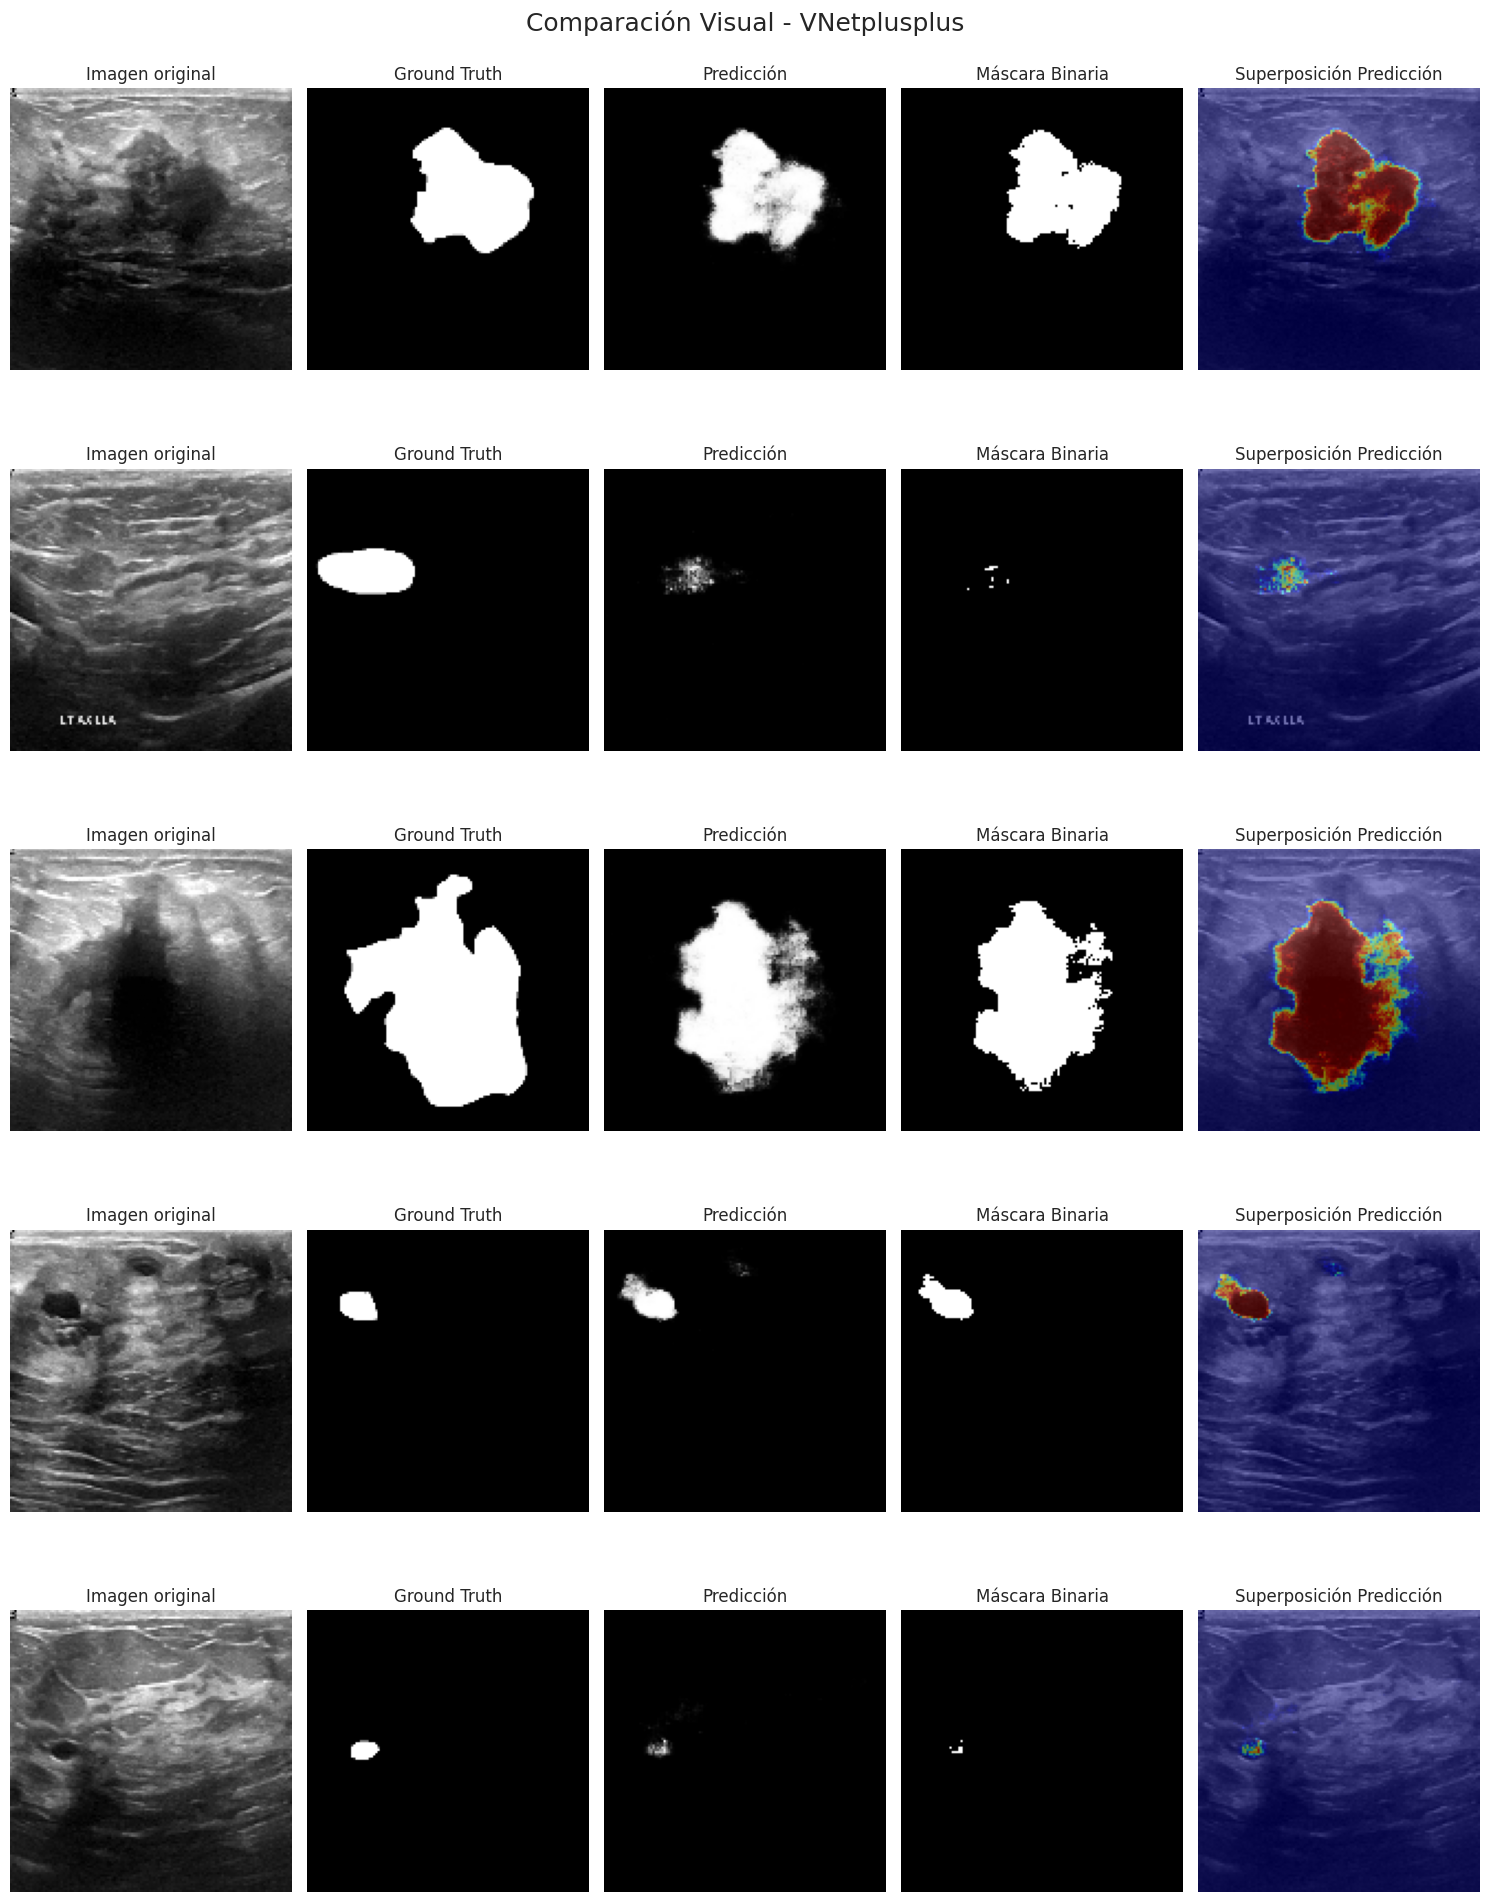

In [33]:
evaluar_modelo(model_vnetpp, X_test, y_test, nombre_modelo="VNetplusplus")

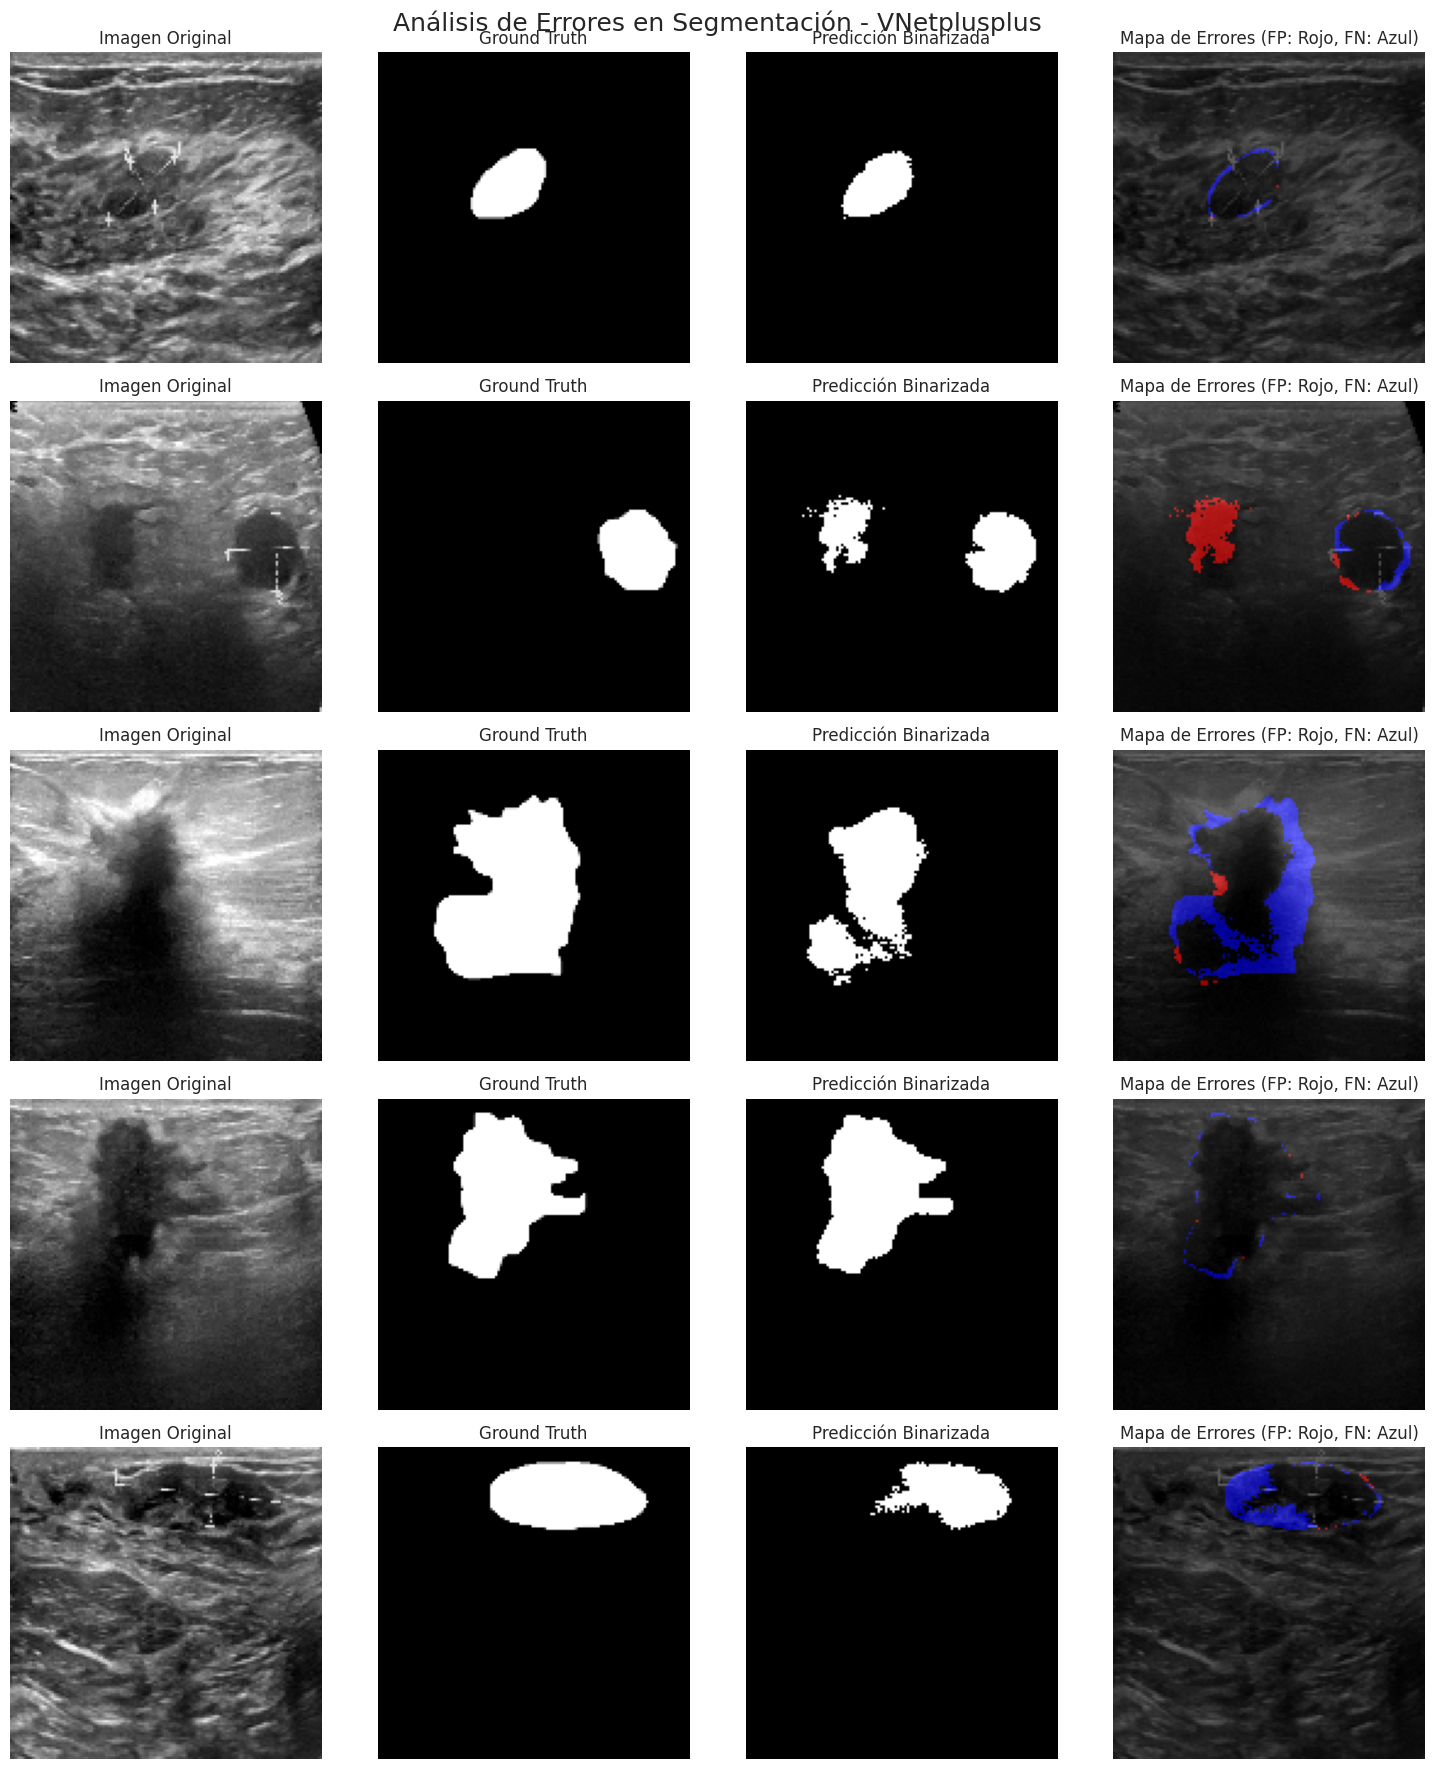

In [34]:
visualizar_segmentacion(model_vnetpp, X_test, y_test, nombre_modelo="VNetplusplus")

Notamos que el modelo predice con alta precisión las estructuras dentro de la imagen, identificando de manera eficaz la región del tumor en la mayoría de los casos. Sin embargo, al analizar los errores más marcados (outliers en el IoU), observamos que las fallas suelen darse en imágenes cuyas máscaras de referencia no logran capturar completamente las estructuras reales presentes. Esto sugiere que, en ciertos casos, el bajo rendimiento del modelo podría no deberse a una deficiencia en su capacidad de segmentación, sino a limitaciones en la calidad o integridad de las anotaciones utilizadas como verdad de terreno. En estos escenarios, el modelo parece ser penalizado injustamente, ya que su predicción puede estar alineada con características visibles en la imagen que la máscara no alcanza a cubrir.

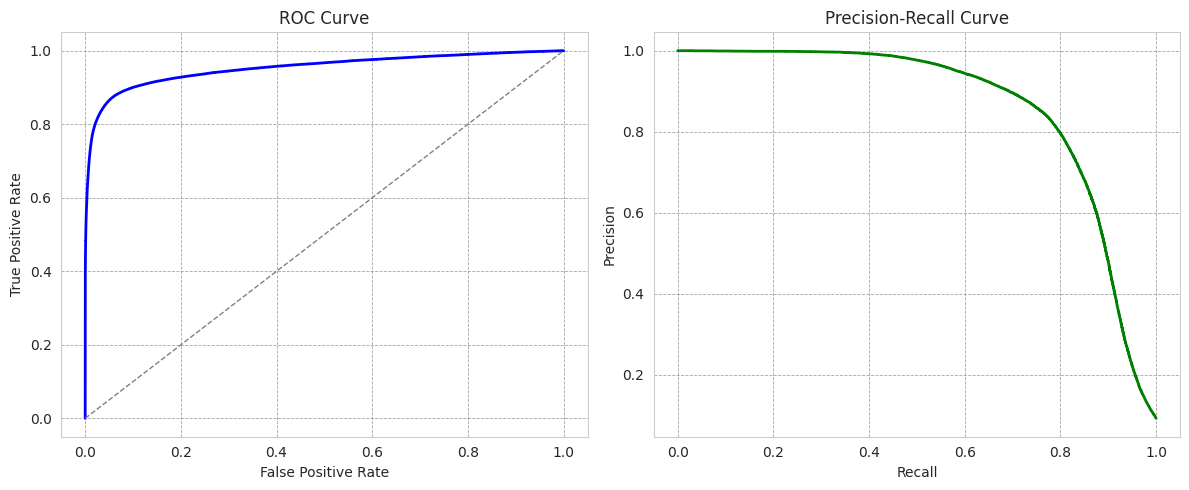

In [35]:
plot_roc_pr_curves(y_test, y_pred)

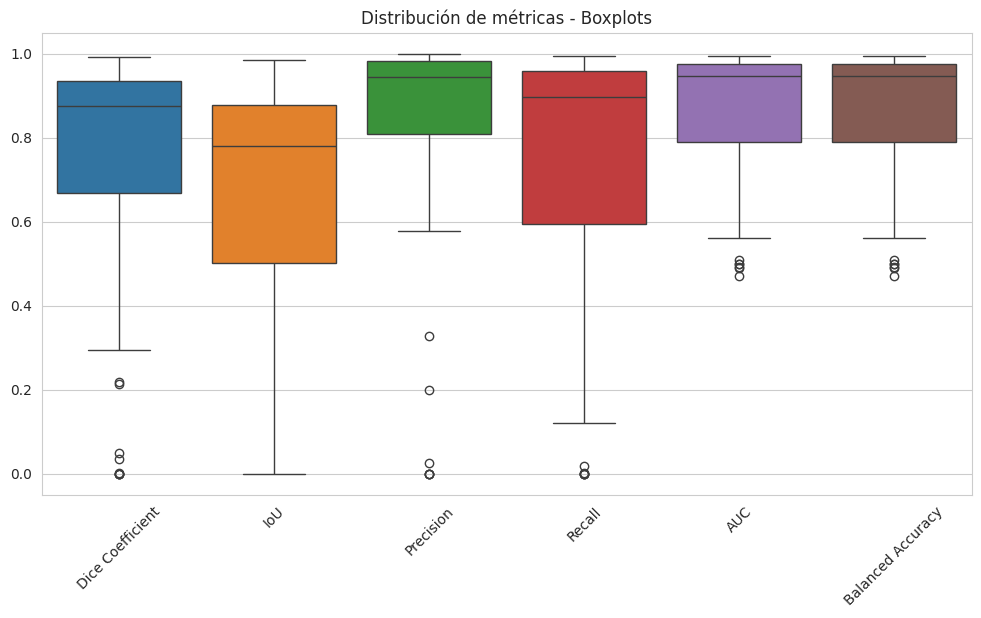

In [36]:
boxplots(y_test, y_pred)

La segunda caja del gráfico corresponde al IoU, cuya mediana ronda el 0.8, indicando que el modelo, en promedio, logra un 80% de superposición entre las máscaras predichas y las reales. El rango intercuartílico va de aproximadamente 0.62 a 0.93, lo que refleja un rendimiento consistente en la mayoría de los casos, aunque la presencia de valores atípicos cercanos a 0 sugiere que en algunas instancias el modelo falla completamente al segmentar.

#### **Interpretación**

Los resultados obtenidos muestran que los modelos desarrollados específicamente para esta tarea lograron un mejor desempeño en comparación con modelos base o de referencia. Las métricas de evaluación reflejan una mayor precisión y capacidad de segmentación, lo que valida tanto el diseño de la arquitectura como los ajustes realizados durante el entrenamiento.

Sin embargo, es importante destacar que la calidad de las máscaras utilizadas durante el entrenamiento juega un papel crucial en el rendimiento del modelo. Modelos con buen diseño pueden verse limitados si las máscaras no están correctamente construidas, ya que esto afecta directamente la capacidad del modelo para aprender patrones relevantes. Por lo tanto, asegurar la precisión y coherencia de las máscaras es esencial para alcanzar un rendimiento óptimo.